<a href="https://colab.research.google.com/github/sathar1919/Data-Science-Projects/blob/main/Facemask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#install kaggle
!pip install kaggle


In [3]:
mkdir -p ~/.kaggle && echo KGAT_71ff1abd75cb0e5823ff282795a92af0 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [4]:
#Importing Face Mask Dataset
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:07<00:00, 21.6MB/s]



In [5]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
!ls

data  face-mask-dataset.zip  sample_data


In [7]:
#Importing the Dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [8]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_441.jpg', 'with_mask_2285.jpg', 'with_mask_1851.jpg', 'with_mask_3717.jpg', 'with_mask_1170.jpg']
['with_mask_3164.jpg', 'with_mask_2674.jpg', 'with_mask_1416.jpg', 'with_mask_683.jpg', 'with_mask_2910.jpg']


In [9]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_172.jpg', 'without_mask_1366.jpg', 'without_mask_1258.jpg', 'without_mask_848.jpg', 'without_mask_450.jpg']
['without_mask_3016.jpg', 'without_mask_647.jpg', 'without_mask_566.jpg', 'without_mask_2328.jpg', 'without_mask_659.jpg']


In [10]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [11]:
#**Creating Labels for the two class of Images**
#with mask  -->  1

#without mask  -->  0

# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [12]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [13]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [14]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


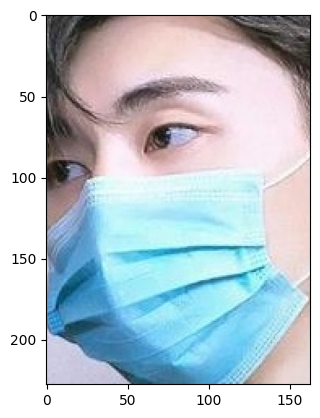

In [15]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

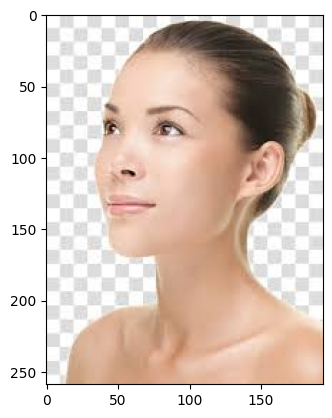

In [16]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [17]:
#**Image Processing**
#1. Resize the Images

#2. Convert the images to numpy arrays

# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [18]:
type(data)

list

In [19]:
len(data)

7553

array([[[ 60, 117, 112],
        [102, 155, 151],
        [ 90, 134, 133],
        ...,
        [ 37,  79,  75],
        [ 46,  90,  85],
        [ 49,  95,  90]],

       [[ 95, 145, 142],
        [113, 158, 157],
        [ 73, 109, 111],
        ...,
        [ 37,  72,  70],
        [ 42,  78,  76],
        [ 45,  83,  81]],

       [[ 73, 114, 113],
        [ 71, 106, 107],
        [ 63,  88,  92],
        ...,
        [ 35,  60,  61],
        [ 37,  65,  65],
        [ 39,  70,  69]],

       ...,

       [[ 63,  47,  54],
        [ 66,  50,  60],
        [ 70,  55,  65],
        ...,
        [ 70,  83,  98],
        [128, 152, 174],
        [150, 180, 210]],

       [[ 67,  49,  57],
        [ 67,  51,  60],
        [ 70,  52,  64],
        ...,
        [ 21,  23,  29],
        [ 43,  52,  63],
        [ 95, 107, 126]],

       [[ 75,  56,  64],
        [ 76,  59,  68],
        [ 79,  61,  74],
        ...,
        [ 20,  15,  21],
        [ 16,  13,  21],
        [ 22,  21,  32]]], dtype=uint8)
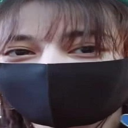

In [20]:
data[0]

In [21]:
type(data[0])

numpy.ndarray

In [22]:
data[0].shape

(128, 128, 3)

In [23]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [25]:
type(X)

numpy.ndarray

In [26]:
type(Y)

numpy.ndarray

In [27]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [28]:
print(Y)

[1 1 1 ... 0 0 0]


In [30]:
#Train and Test Spilt
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [31]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [32]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [36]:
print(X_train_scaled)
print(X_test_scaled)

[[[[0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   ...
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]]

  [[0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   ...
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]]

  [[0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   ...
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]]

  ...

  [[0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   ...
   [0.         0.         0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]]

  [[0.         0.         0.        ]
   [0. 

array([[[ 67,  59,  57],
        [ 65,  57,  53],
        [ 60,  53,  47],
        ...,
        [254, 255, 255],
        [253, 255, 255],
        [253, 255, 254]],

       [[ 48,  39,  36],
        [ 46,  38,  33],
        [ 44,  37,  30],
        ...,
        [254, 255, 255],
        [254, 255, 255],
        [254, 255, 255]],

       [[ 40,  31,  25],
        [ 39,  30,  25],
        [ 38,  30,  25],
        ...,
        [254, 255, 255],
        [254, 255, 255],
        [254, 255, 255]],

       ...,

       [[172, 137, 100],
        [171, 137, 100],
        [173, 139, 104],
        ...,
        [245, 250, 254],
        [246, 251, 255],
        [246, 251, 255]],

       [[177, 144, 109],
        [176, 143, 107],
        [176, 143, 109],
        ...,
        [243, 250, 255],
        [244, 251, 255],
        [244, 251, 255]],

       [[194, 161, 126],
        [190, 157, 122],
        [185, 152, 117],
        ...,
        [242, 249, 255],
        [243, 250, 255],
        [243, 250, 255]]], dtype=uint8)
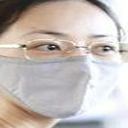

In [39]:
X_train[5]

In [40]:
X_train_scaled[2]

array([[[0.14117647, 0.11372549, 0.08235294],
        [0.16078431, 0.13333333, 0.10196078],
        [0.18431373, 0.15686275, 0.1254902 ],
        ...,
        [0.04313725, 0.04313725, 0.02745098],
        [0.04705882, 0.04313725, 0.03137255],
        [0.04313725, 0.04313725, 0.03529412]],

       [[0.16078431, 0.13333333, 0.09803922],
        [0.18823529, 0.16078431, 0.12156863],
        [0.21960784, 0.19215686, 0.15294118],
        ...,
        [0.04313725, 0.04313725, 0.03529412],
        [0.04313725, 0.04313725, 0.03529412],
        [0.03921569, 0.04313725, 0.03529412]],

       [[0.21176471, 0.18431373, 0.14509804],
        [0.23137255, 0.20784314, 0.16078431],
        [0.23137255, 0.20784314, 0.16078431],
        ...,
        [0.03921569, 0.04705882, 0.03921569],
        [0.03921569, 0.04705882, 0.04313725],
        [0.03921569, 0.04313725, 0.03921569]],

       ...,

       [[0.72156863, 0.5254902 , 0.51372549],
        [0.63137255, 0.43921569, 0.42352941],
        [0.55294118, 0

**Building a Convolutional Neural Networks (CNN)**

In [41]:
import tensorflow as tf
from tensorflow import keras

In [42]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [44]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - acc: 0.7694 - loss: 0.5103 - val_acc: 0.9058 - val_loss: 0.2514
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8751 - loss: 0.3225 - val_acc: 0.9025 - val_loss: 0.2385
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8939 - loss: 0.2732 - val_acc: 0.8760 - val_loss: 0.3102
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9034 - loss: 0.2480 - val_acc: 0.9289 - val_loss: 0.1940
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9150 - loss: 0.2090 - val_acc: 0.9273 - val_loss: 0.2120


In [45]:
#Model Evaluation
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9206 - loss: 0.2466
Test Accuracy = 0.9205824136734009


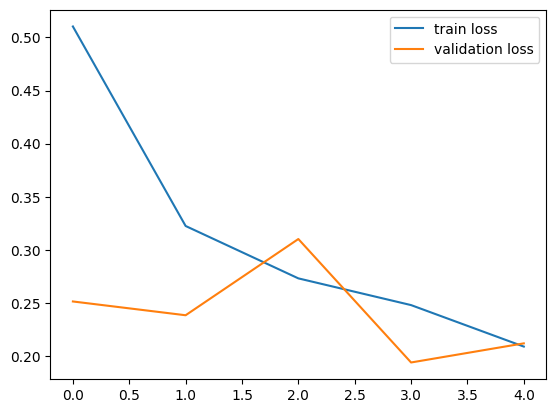

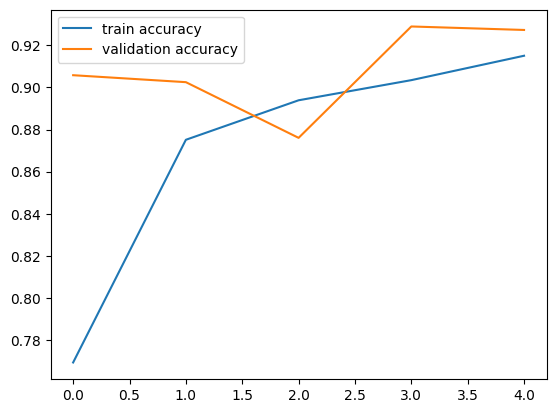

In [46]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

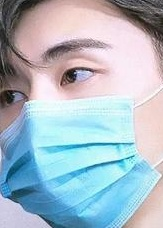

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.85068876 0.14220971]]
0
The person in the image is not wearing a mask


In [53]:
input_image_path = '/content/data/with_mask/with_mask_1545.jpg' #input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

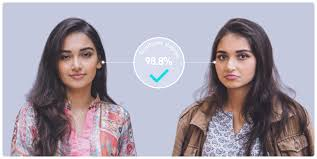

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.6020696  0.38765764]]
0
The person in the image is not wearing a mask


In [60]:
input_image_path = '/content/data/without_mask/without_mask_1925.jpg' #input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')